# *TASK 4*
Data visualisation using numpy, pandas, matplotlib and seaborn.

## Initializing libraries

In [2]:
# if you get an error here, please try importing all the modules first
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

## 1. Create a 5×5 random-integer matrix and a student DataFrame (name, subject, marks, attendance %; 15+ rows). Then: 
i. Explore the matrix: transpose, row/column sums, max value's position.\
ii. Clean and analyze the DataFrame: handle missing marks, average marks per subject, low-attendance students, pass/fail column, top 5 by marks.\
iii. Visualize: a line plot of any trend, plus a bar chart + histogram subplot, with one plot customized (color, marker, legend).

--- MATRIX ANALYSIS ---
Original Matrix:
 [[ 1 52 82 69 92]
 [49 65 71 71 35]
 [93 81 30  7 87]
 [32 47 49 92 29]
 [59 16 31 67 19]]

Transposed Matrix:
 [[ 1 49 93 32 59]
 [52 65 81 47 16]
 [82 71 30 49 31]
 [69 71  7 92 67]
 [92 35 87 29 19]]

Row Sums: [296 291 298 249 192]
Column Sums: [234 261 263 306 262]
Max Value Position (Row, Col): (np.int64(2), np.int64(0)) (Value: 93)

--- STUDENT DATAFRAME ANALYSIS ---

Average Marks Per Subject:
 Subject
Chemistry    65.400000
Math         85.600000
Physics      68.333333
Name: Marks, dtype: float64

Low Attendance (<75%) Students:
        Name  Attendance_%
2   Charlie            70
4       Eva            60
9      Jack            65
13     Noah            72

Top 5 Students by Marks:
       Name  Marks
8      Ian   95.0
3    David   92.0
15   Peter   91.0
14  Olivia   89.0
7   Hannah   88.0


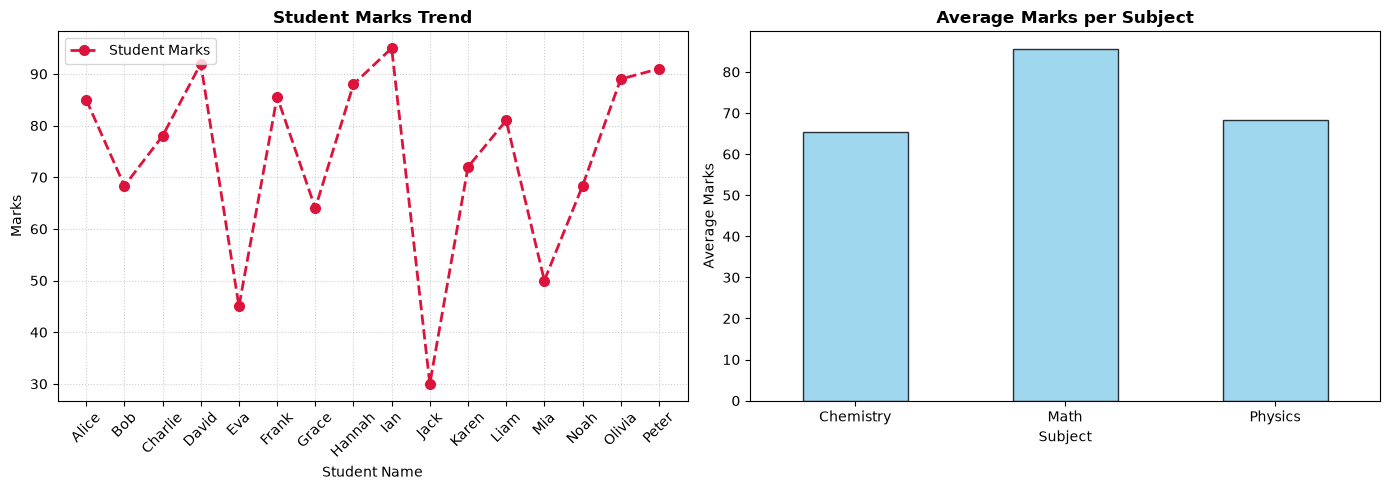

In [3]:
np.random.seed(48)
matrix = np.random.randint(1, 100, size=(5, 5))

transpose_matrix = matrix.T
row_sums = matrix.sum(axis=1)
col_sums = matrix.sum(axis=0)
max_idx = np.unravel_index(np.argmax(matrix), matrix.shape)

print("--- MATRIX ANALYSIS ---")
print("Original Matrix:\n", matrix)
print("\nTransposed Matrix:\n", transpose_matrix)
print("\nRow Sums:", row_sums)
print("Column Sums:", col_sums)
print(f"Max Value Position (Row, Col): {max_idx} (Value: {matrix[max_idx]})")


data = {
    "Name": ["Alice", "Bob","Charlie","David","Eva","Frank","Grace","Hannah","Ian","Jack","Karen","Liam","Mia","Noah","Olivia","Peter",],
    "Subject": ["Math","Physics","Math","Chemistry","Physics","Math","Chemistry",
                "Physics","Math", "Chemistry", "Physics","Math","Chemistry","Physics","Math","Chemistry",],
    "Marks": [85,"N/A",78,92,45,"N/A",64,88,95,30,72,81,50,"N/A",89,91,],
    "Attendance_%": [90, 85, 70, 95, 60, 75, 80, 92, 98, 65, 88, 79, 83, 72, 91, 94],
}
df = pd.DataFrame(data)
df["Marks"] = pd.to_numeric(df["Marks"], errors="coerce")
df["Marks"] = df.groupby("Subject")["Marks"].transform(lambda x: x.fillna(x.mean()))

avg_marks_per_subject = df.groupby("Subject")["Marks"].mean()
low_attendance_students = df[df["Attendance_%"] < 75]
df["Status"] = np.where(df["Marks"] >= 40, "Pass", "Fail")
top_5_students = df.nlargest(5, "Marks")

print("\n--- STUDENT DATAFRAME ANALYSIS ---")
print("\nAverage Marks Per Subject:\n", avg_marks_per_subject)
print("\nLow Attendance (<75%) Students:\n", low_attendance_students[["Name", "Attendance_%"]])
print("\nTop 5 Students by Marks:\n", top_5_students[["Name", "Marks"]])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    df["Name"],
    df["Marks"],
    color="crimson",
    marker="o",
    linestyle="--",
    linewidth=2,
    markersize=7,
    label="Student Marks",
)

axes[0].set_title("Student Marks Trend", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Student Name")
axes[0].set_ylabel("Marks")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(True, linestyle=":", alpha=0.6)
axes[0].legend(loc="upper left")

avg_marks_per_subject.plot(
    kind="bar", ax=axes[1], color="skyblue", edgecolor="black", alpha=0.8
)
axes[1].set_title("Average Marks per Subject", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Subject")
axes[1].set_ylabel("Average Marks")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 2. You will be given the WorldHappinessReport dataset. You will need to:
i. Track the performance of the happiest and least happiest country in 2015 and the performance of the happiest and least happiest country in 2019. Track across multiple features. \
ii. Determine which region of the world is happiest considering data from all 5 years. \
iii. Determine the composition of the top 10 countries regionwise across all 5 years. \
iv. What is the happiest country in Latin America and the Caribbean in each year and overall, considering all 5 years of data.

In [4]:
def get_country_metrics(df, country, country_col, score_col, gdp_col, health_col, freedom_col):
    row = df[df[country_col] == country]
    if len(row) > 0:
        return [
            row[score_col].values[0],
            row[gdp_col].values[0],
            row[health_col].values[0],
            row[freedom_col].values[0]
        ]
    return [np.nan, np.nan, np.nan, np.nan]

=== i ===


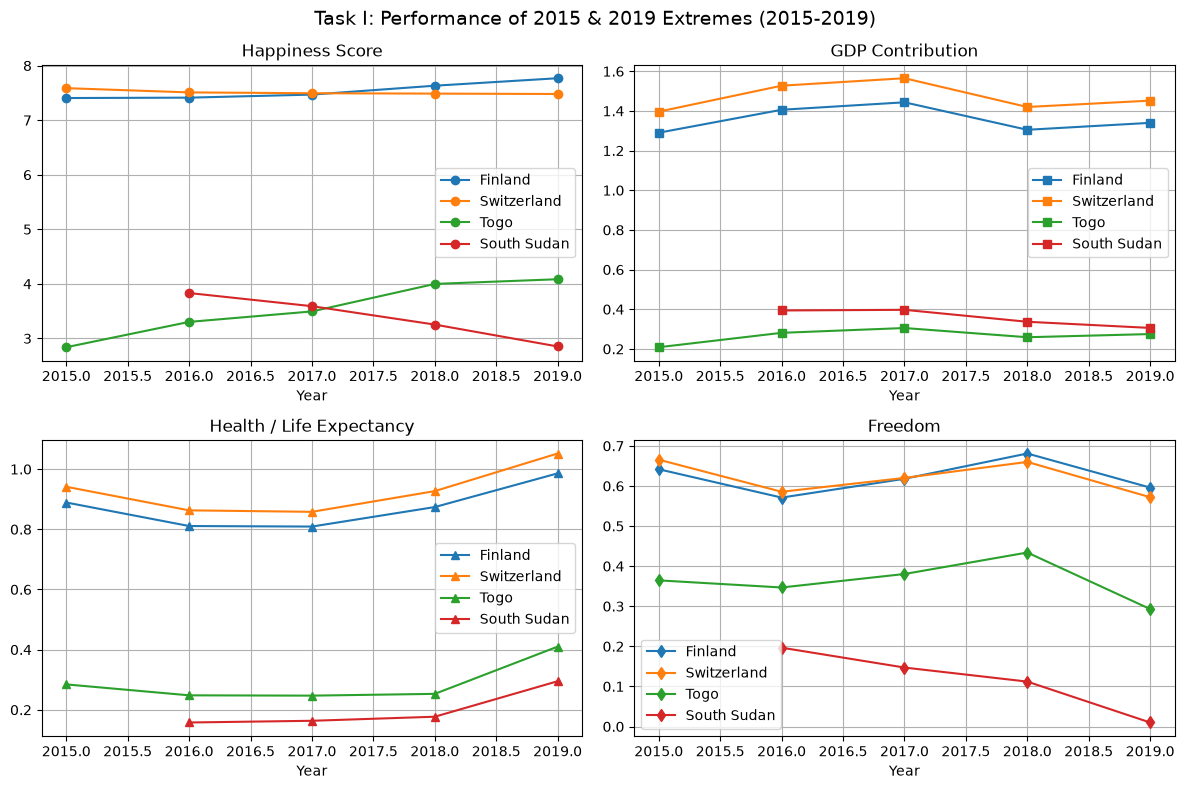


=== ii ===
5-Year Average Happiness Score per Region:
Region
Australia and New Zealand          7.294600
North America                      7.174700
Western Europe                     6.761300
Latin America and Caribbean        6.017084
Eastern Asia                       5.621533
Central and Eastern Europe         5.429861
Southeastern Asia                  5.337664
Middle East and Northern Africa    5.336475
Southern Asia                      4.580657
Sub-Saharan Africa                 4.188142
dtype: float64

Happiest Region Overall: Australia and New Zealand 7.294600004959106


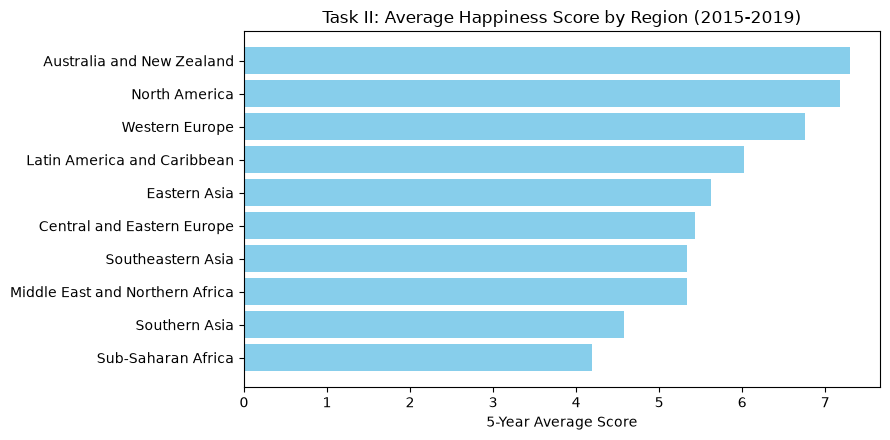


=== iii ===
                           2015  2016  2017  2018  2019
Region                                                 
Western Europe                7     7     7     7     8
Australia and New Zealand     2     2     2     2     1
North America                 1     1     1     1     1


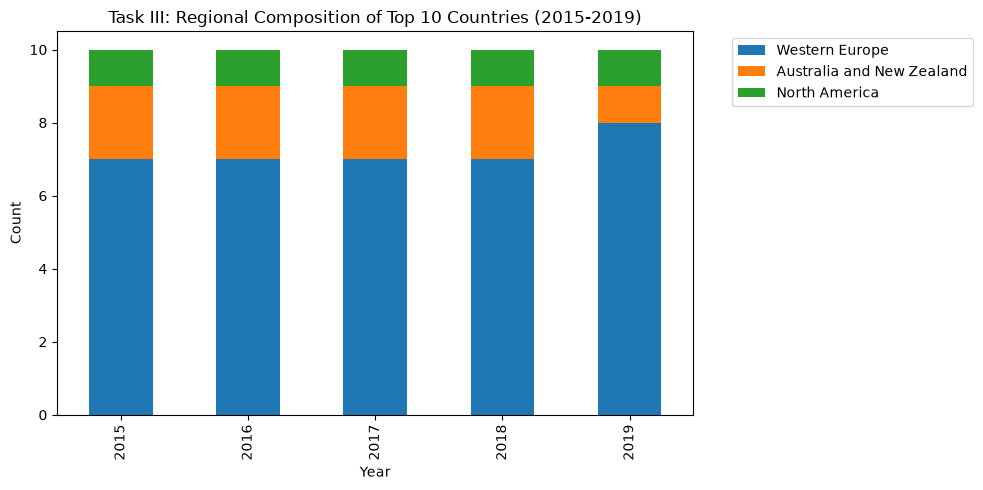


=== iv ===
Yearly Top Country in LAC:
2015: Costa Rica 7.226
2016: Costa Rica 7.087
2017: Costa Rica 7.0789999961853
2018: Costa Rica 7.072
2019: Costa Rica 7.167

Happiest Country in LAC Overall (5-Year Average): Costa Rica 7.126199999237059


In [6]:
df_2015 = pd.read_csv('2015.csv')
df_2016 = pd.read_csv('2016.csv')
df_2017 = pd.read_csv('2017.csv')
df_2018 = pd.read_csv('2018.csv')
df_2019 = pd.read_csv('2019.csv')

country_to_region = dict(zip(df_2015['Country'], df_2015['Region']))
country_to_region.update(dict(zip(df_2016['Country'], df_2016['Region'])))

print("=== i ===")
h2015 = df_2015.sort_values('Happiness Score', ascending=False).iloc[0]['Country']
l2015 = df_2015.sort_values('Happiness Score', ascending=False).iloc[-1]['Country']
h2019 = df_2019.sort_values('Score', ascending=False).iloc[0]['Country or region']
l2019 = df_2019.sort_values('Score', ascending=False).iloc[-1]['Country or region']
target_countries = list(set([h2015, l2015, h2019, l2019]))
years = [2015, 2016, 2017, 2018, 2019]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Task I: Performance of 2015 & 2019 Extremes (2015-2019)', fontsize=14)
feature_labels = ['Happiness Score', 'GDP Contribution', 'Health / Life Expectancy', 'Freedom']

for c in target_countries:
    data = np.array([
        get_country_metrics(df_2015, c, 'Country', 'Happiness Score', 'Economy (GDP per Capita)', 'Health (Life Expectancy)', 'Freedom'),
        get_country_metrics(df_2016, c, 'Country', 'Happiness Score', 'Economy (GDP per Capita)', 'Health (Life Expectancy)', 'Freedom'),
        get_country_metrics(df_2017, c, 'Country', 'Happiness.Score', 'Economy..GDP.per.Capita.', 'Health..Life.Expectancy.', 'Freedom'),
        get_country_metrics(df_2018, c, 'Country or region', 'Score', 'GDP per capita', 'Healthy life expectancy', 'Freedom to make life choices'),
        get_country_metrics(df_2019, c, 'Country or region', 'Score', 'GDP per capita', 'Healthy life expectancy', 'Freedom to make life choices')
    ])
    
    axes[0, 0].plot(years, data[:, 0], marker='o', label=c)
    axes[0, 1].plot(years, data[:, 1], marker='s', label=c)
    axes[1, 0].plot(years, data[:, 2], marker='^', label=c)
    axes[1, 1].plot(years, data[:, 3], marker='d', label=c)

for idx, ax in enumerate(axes.flat):
    ax.set_title(feature_labels[idx])
    ax.set_xlabel('Year')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

print("\n=== ii ===")

r15 = df_2015.groupby('Region')['Happiness Score'].mean()
r16 = df_2016.groupby('Region')['Happiness Score'].mean()

r17_temp = df_2017.copy()
r17_temp['Region'] = r17_temp['Country'].map(country_to_region)
r17 = r17_temp.groupby('Region')['Happiness.Score'].mean()

r18_temp = df_2018.copy()
r18_temp['Region'] = r18_temp['Country or region'].map(country_to_region)
r18 = r18_temp.groupby('Region')['Score'].mean()

r19_temp = df_2019.copy()
r19_temp['Region'] = r19_temp['Country or region'].map(country_to_region)
r19 = r19_temp.groupby('Region')['Score'].mean()

regional_5yr_avg = pd.concat([r15, r16, r17, r18, r19], axis=1).mean(axis=1).sort_values(ascending=False)
print("5-Year Average Happiness Score per Region:")
print(regional_5yr_avg)
print("\nHappiest Region Overall:",regional_5yr_avg.index[0],regional_5yr_avg.iloc[0])

plt.figure(figsize=(9, 4.5))
plt.barh(regional_5yr_avg.index[::-1], regional_5yr_avg.values[::-1], color='skyblue')
plt.title('Task II: Average Happiness Score by Region (2015-2019)')
plt.xlabel('5-Year Average Score')
plt.tight_layout()
plt.show()

print("\n=== iii ===")

top10_15 = df_2015.nlargest(10, 'Happiness Score')['Region'].value_counts()
top10_16 = df_2016.nlargest(10, 'Happiness Score')['Region'].value_counts()
top10_17 = r17_temp.nlargest(10, 'Happiness.Score')['Region'].value_counts()
top10_18 = r18_temp.nlargest(10, 'Score')['Region'].value_counts()
top10_19 = r19_temp.nlargest(10, 'Score')['Region'].value_counts()

top10_comp = pd.DataFrame({
    2015: top10_15, 2016: top10_16, 2017: top10_17, 2018: top10_18, 2019: top10_19
}).fillna(0)

print(top10_comp)

top10_comp.T.plot(kind='bar', stacked=True, figsize=(10, 5))
plt.title('Task III: Regional Composition of Top 10 Countries (2015-2019)')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


print("\n=== iv ===")

lac_15 = df_2015[df_2015['Region'] == 'Latin America and Caribbean'].sort_values('Happiness Score', ascending=False).iloc[0]
lac_16 = df_2016[df_2016['Region'] == 'Latin America and Caribbean'].sort_values('Happiness Score', ascending=False).iloc[0]
lac_17 = r17_temp[r17_temp['Region'] == 'Latin America and Caribbean'].sort_values('Happiness.Score', ascending=False).iloc[0]
lac_18 = r18_temp[r18_temp['Region'] == 'Latin America and Caribbean'].sort_values('Score', ascending=False).iloc[0]
lac_19 = r19_temp[r19_temp['Region'] == 'Latin America and Caribbean'].sort_values('Score', ascending=False).iloc[0]

print("Yearly Top Country in LAC:")
print("2015:",lac_15['Country'],lac_15['Happiness Score'])
print("2016:",lac_16['Country'],lac_16['Happiness Score'])
print("2017:",lac_17['Country'],lac_17['Happiness.Score'])
print("2018:",lac_18['Country or region'],lac_18['Score'])
print("2019:",lac_19['Country or region'],lac_19['Score'])

lac_all_15 = df_2015[df_2015['Region'] == 'Latin America and Caribbean'].set_index('Country')['Happiness Score']
lac_all_16 = df_2016[df_2016['Region'] == 'Latin America and Caribbean'].set_index('Country')['Happiness Score']
lac_all_17 = r17_temp[r17_temp['Region'] == 'Latin America and Caribbean'].set_index('Country')['Happiness.Score']
lac_all_18 = r18_temp[r18_temp['Region'] == 'Latin America and Caribbean'].set_index('Country or region')['Score']
lac_all_19 = r19_temp[r19_temp['Region'] == 'Latin America and Caribbean'].set_index('Country or region')['Score']

lac_overall_avg = pd.concat([lac_all_15, lac_all_16, lac_all_17, lac_all_18, lac_all_19], axis=1).mean(axis=1).sort_values(ascending=False)

print("\nHappiest Country in LAC Overall (5-Year Average):",lac_overall_avg.index[0],lac_overall_avg.iloc[0])